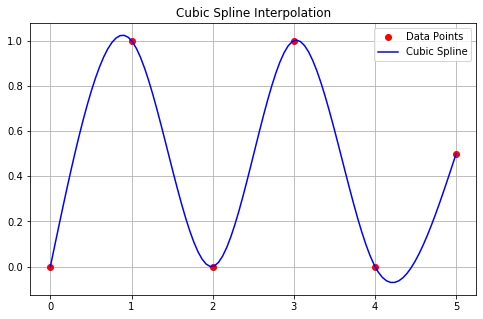

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Define Known Data Points
x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 1, 0, 1, 0, 0.5])

# Step 2: Calculate Step Sizes
# hi = xi+1 - xi
n = len(x)
h = np.diff(x)

# Step 3: Set Up and Solve the Tridiagonal System
def solve_system(x, y, h):
    n = len(x)
    # The system solves for internal second derivatives M (size n-2)
    num_internal = n - 2
    A = np.zeros(num_internal - 1)  # Subdiagonal
    B = np.zeros(num_internal)      # Main diagonal
    C = np.zeros(num_internal - 1)  # Superdiagonal
    D = np.zeros(num_internal)      # Right-hand side vector
    
    # Populate coefficients
    for i in range(1, n - 1):
        idx = i - 1
        B[idx] = 2 * (h[i-1] + h[i])
        D[idx] = 6 * ((y[i+1] - y[i])/h[i] - (y[i] - y[i-1])/h[i-1])
        if idx > 0:
            A[idx-1] = h[i-1]
        if idx < num_internal - 1:
            C[idx] = h[i]
            
    # Thomas Algorithm
    # Forward elimination
    for i in range(1, num_internal):
        w = A[i-1] / B[i-1]
        B[i] = B[i] - w * C[i-1]
        D[i] = D[i] - w * D[i-1]
    
    # Back substitution
    M_internal = np.zeros(num_internal)
    M_internal[-1] = D[-1] / B[-1]
    for i in range(num_internal - 2, -1, -1):
        M_internal[i] = (D[i] - C[i] * M_internal[i+1]) / B[i]
        
    # Natural Boundary Conditions
    M = np.zeros(n)
    M[1:-1] = M_internal
    return M

M = solve_system(x, y, h)

# Step 4: Evaluate the Spline at New Points
def evaluate_spline(x_data, y_data, M, h, x_eval):
    y_plot = []
    for val in x_eval:
        # Find the correct interval
        i = np.searchsorted(x_data, val) - 1
        i = max(0, min(i, len(x_data) - 2))
        
        # Calculate coefficients for Si(x) = a + b(dx) + c(dx)^2 + d(dx)^3
        dx = val - x_data[i]
        a_i = y_data[i]
        b_i = (y_data[i+1] - y_data[i])/h[i] - h[i]*(2*M[i] + M[i+1])/6
        c_i = M[i] / 2
        d_i = (M[i+1] - M[i]) / (6 * h[i])
        
        y_val = a_i + b_i*dx + c_i*(dx**2) + d_i*(dx**3)
        y_plot.append(y_val)
    return np.array(y_plot)

# Plot the Results
x_eval = np.linspace(min(x), max(x), 100)
y_eval = evaluate_spline(x, y, M, h, x_eval)

plt.figure(figsize=(8, 5))
plt.plot(x, y, 'ro', label='Data Points')
plt.plot(x_eval, y_eval, 'b-', label='Cubic Spline')
plt.legend()
plt.grid(True)
plt.title("Cubic Spline Interpolation")
plt.show()